In [1]:
import pandas as pd

df = pd.read_excel(r"C:\Users\Admin\Documents\Thesis\start-end.xlsx")

df.columns = df.columns.str.strip()

In [2]:
df = df.rename(columns={
    "Unnamed: 0": "event_type",
    "Line (Excel file)": "file_id"
})

In [3]:
df["event_type"] = df["event_type"].ffill()

In [4]:
#clean data
df = df.dropna(subset=["file_id"])

df["file_id"] = df["file_id"].astype(int).astype(str)
df["event_type"] = df["event_type"].astype(str).str.strip()

In [5]:
df = df[df["event_type"].isin(["ESz", "IED"])]

In [6]:
def time_to_seconds(t):
    if pd.isna(t):
        return None
    
    t = str(t).replace("’", ":").replace("”", "")
    
    try:
        m, s = t.split(":")
        return int(m)*60 + int(s)
    except:
        return None

df["start_sec"] = df["Start"].apply(time_to_seconds)
df["end_sec"] = df["end"].apply(time_to_seconds)

df = df.dropna(subset=["start_sec", "end_sec"])

In [7]:
print("Total seizure annotations:", len(df))

Total seizure annotations: 23


In [8]:
print(df.head(10))

    event_type file_id  Start     end  start_sec  end_sec
0          ESz      81  5’05”  10’07”      305.0    607.0
1          ESz     308  5’43”   8’07”      343.0    487.0
2          ESz     311  9’33”  11’07”      573.0    667.0
3          ESz     357  9’27”  11’02”      567.0    662.0
5          IED      83  6’06”   6’10”      366.0    370.0
14         IED      84  0’05”   0’08”        5.0      8.0
72         IED     101  1’17”   1’18”       77.0     78.0
81         IED     119  0’26”   0’27”       26.0     27.0
155        IED     137  2’25”   2’26”      145.0    146.0
159        IED     139  0’45”   0’53”       45.0     53.0


In [9]:
import os

def get_intervals(file_path, df):
    
    file_name = os.path.basename(file_path)
    file_id = file_name.split("_")[0]   
    
    rows = df[df["file_id"] == file_id]
    
    intervals = [(r["start_sec"], r["end_sec"]) for _, r in rows.iterrows()]
    
    return intervals

In [10]:
import glob

edf_files = glob.glob(r"C:\Users\Admin\Documents\Thesis\data\raw\*.edf")

print("Total EDF files:", len(edf_files))
print(edf_files[:5])  # preview first 5 file paths

Total EDF files: 351
['C:\\Users\\Admin\\Documents\\Thesis\\data\\raw\\100_byte_anon.edf', 'C:\\Users\\Admin\\Documents\\Thesis\\data\\raw\\101_byte_anon.edf', 'C:\\Users\\Admin\\Documents\\Thesis\\data\\raw\\102_byte_anon.edf', 'C:\\Users\\Admin\\Documents\\Thesis\\data\\raw\\103_byte_anon.edf', 'C:\\Users\\Admin\\Documents\\Thesis\\data\\raw\\104_byte_anon.edf']


In [11]:
test_file = edf_files[0]

intervals = get_intervals(test_file, df)

print("File:", test_file)
print("Intervals:", intervals)

File: C:\Users\Admin\Documents\Thesis\data\raw\100_byte_anon.edf
Intervals: []


In [26]:
TARGET_CHANNELS = 16  

In [27]:
def process_file(file_path, df, window_size=3):
    
    raw = mne.io.read_raw_edf(file_path, preload=True)
    
    sfreq = raw.info['sfreq']
    data = raw.get_data()
    
    samples = int(window_size * sfreq)
    step = samples // 2   
    
    intervals = get_intervals(file_path, df)
    
    segments = []
    labels = []
    
    for start in range(0, data.shape[1] - samples, step):
        
        end = start + samples
        
        segment = data[:, start:end]

# Ensure correct length
        if segment.shape[1] < samples:
            continue

# 🔥 FORCE SAME NUMBER OF CHANNELS
        if segment.shape[0] >= TARGET_CHANNELS:
            segment = segment[:TARGET_CHANNELS, :]
        else:
            continue
        
        start_time = start / sfreq
        end_time = end / sfreq
        
        label = 0
        
        for s_start, s_end in intervals:
            
            overlap = max(0, min(end_time, s_end) - max(start_time, s_start))
            
            if overlap > 0:
                label = 1
                break
        
        segments.append(segment)
        labels.append(label)
    
    return segments, labels

In [28]:
all_segments = []
all_labels = []
file_ids = []

for file_path in edf_files:
    
    segs, labs = process_file(file_path, df, window_size=3)
    
    all_segments.extend(segs)
    all_labels.extend(labs)
    file_ids.extend([file_path]*len(labs))

Extracting EDF parameters from C:\Users\Admin\Documents\Thesis\data\raw\100_byte_anon.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 300499  =      0.000 ...   600.998 secs...
Extracting EDF parameters from C:\Users\Admin\Documents\Thesis\data\raw\101_byte_anon.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 306499  =      0.000 ...   612.998 secs...
Extracting EDF parameters from C:\Users\Admin\Documents\Thesis\data\raw\102_byte_anon.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 300999  =      0.000 ...   601.998 secs...
Extracting EDF parameters from C:\Users\Admin\Documents\Thesis\data\raw\103_byte_anon.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 303499  =      0.000 ...   606.998 secs...
Extracting EDF parameters from C:\Users\Admin\Documents\Thesis\data\raw\104_byte_anon.edf...
Setting channel info structure...
Creating raw.

In [29]:
print("Total segments:", len(all_labels))
print("Seizure segments:", sum(all_labels))

Total segments: 182248
Seizure segments: 493


In [30]:
def extract_features(seg):
    
    
    return np.concatenate([
        np.mean(seg, axis=1),
        np.std(seg, axis=1)
    ])

In [31]:
feature_list = []
label_list = []
file_list = []

for seg, lab, fid in zip(all_segments, all_labels, file_ids):
    
    f = extract_features(seg)
    
 
    if f is None or len(f) == 0:
        continue
    
    feature_list.append(f)
    label_list.append(lab)
    file_list.append(fid)

In [32]:
print("Number of features collected:", len(feature_list))

Number of features collected: 182248


In [33]:
print("Total segments:", len(all_segments))
print("First segment shape:", all_segments[0].shape if len(all_segments)>0 else "None")

Total segments: 182248
First segment shape: (16, 1500)


In [34]:
X = np.vstack([extract_features(seg) for seg in all_segments])
y = np.array(all_labels)
file_ids = np.array(file_ids)

In [35]:
print("X shape:", X.shape)
print("Unique labels:", np.unique(y, return_counts=True))

X shape: (182248, 32)
Unique labels: (array([0, 1]), array([181755,    493]))


In [36]:
# PATIENT-LEVEL SPLIT

from sklearn.model_selection import train_test_split
import numpy as np

unique_files = np.unique(file_ids)

train_files, test_files = train_test_split(
    unique_files, test_size=0.2, random_state=42
)

train_mask = np.isin(file_ids, train_files)
test_mask = np.isin(file_ids, test_files)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

In [ ]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import precision_recall_curve

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     35942
           1       0.00      0.00      0.00        11

    accuracy                           1.00     35953
   macro avg       0.50      0.50      0.50     35953
weighted avg       1.00      1.00      1.00     35953

AUC: 0.21906632402709414


c:\Users\Admin\Documents\Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\Documents\Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\Documents\Thesis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [ ]:
# LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("\nLogistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, y_prob_lr))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.61      0.76     35942
           1       0.00      0.27      0.00        11

    accuracy                           0.61     35953
   macro avg       0.50      0.44      0.38     35953
weighted avg       1.00      0.61      0.76     35953

AUC: 0.369033948634416


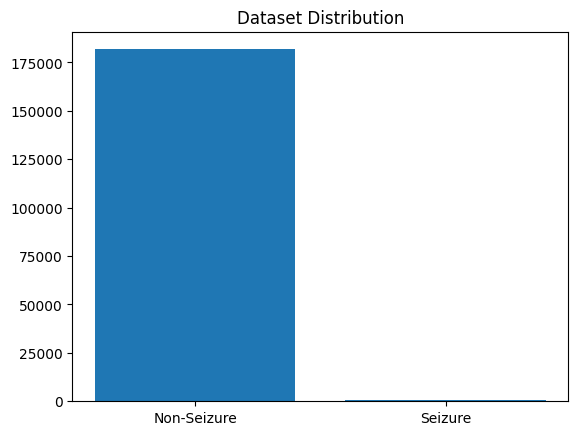

In [39]:
import matplotlib.pyplot as plt

plt.bar(["Non-Seizure", "Seizure"],
        [np.sum(y == 0), np.sum(y == 1)])

plt.title("Dataset Distribution")
plt.show()